In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
import json

kaggle_data = {
    "username": "nelloreganesh",
    "key": "KGAT_5f103d9acb940bed87f96e26db32c41a"
}

with open("kaggle.json", "w") as f:
    json.dump(kaggle_data, f)


In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


In [ ]:
!kaggle datasets download -d paultimothymooney/blood-cells


Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/blood-cells
License(s): other
  0% 0.00/108M [00:00<?, ?B/s]
100% 108M/108M [00:00<00:00, 1.74GB/s]


In [ ]:
!unzip blood-cells.zip


Streaming output truncated to the last 5000 lines.
  inflating: dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8050.jpeg  
  inflating: dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8167.jpeg  
  inflating: dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8283.jpeg  
  inflating: dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8324.jpeg  
  inflating: dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8379.jpeg  
  inflating: dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8577.jpeg  
  inflating: dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8587.jpeg  
  inflating: dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8655.jpeg  
  inflating: dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8701.jpeg  
  inflating: dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_872.jpeg  
  inflating: dataset2-master/dataset2-master/images/TRAIN/LYMPHOCYTE/_9_8864.jpeg  
  inflating: dataset2-mast

In [ ]:
import os

print(os.listdir())


['.config', 'dataset-master', 'kaggle.json', 'dataset2-master', 'blood-cells.zip', 'sample_data']


In [ ]:
import os

base_path = "dataset2-master/dataset2-master/images/TRAIN"
print(os.listdir(base_path))


['LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL', 'EOSINOPHIL']


In [ ]:
import os
import pandas as pd

data_dir = "dataset2-master/dataset2-master/images/TRAIN"
class_labels = ['EOSINOPHIL', 'LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL']

filepaths = []
labels = []

for label in class_labels:
    class_dir = os.path.join(data_dir, label)
    for file in os.listdir(class_dir):
        if file.lower().endswith(('.jpeg', '.jpg', '.png')):
            filepaths.append(os.path.join(class_dir, file))
            labels.append(label)

bloodCell_df = pd.DataFrame({
    'filepaths': filepaths,
    'labels': labels
})

bloodCell_df = bloodCell_df.sample(frac=1).reset_index(drop=True)

print("Total Images:", len(bloodCell_df))
bloodCell_df.head()


Total Images: 9957


,filepaths,labels
0,dataset2-master/dataset2-master/images/TRAIN/M...,MONOCYTE
1,dataset2-master/dataset2-master/images/TRAIN/N...,NEUTROPHIL
2,dataset2-master/dataset2-master/images/TRAIN/M...,MONOCYTE
3,dataset2-master/dataset2-master/images/TRAIN/E...,EOSINOPHIL
4,dataset2-master/dataset2-master/images/TRAIN/L...,LYMPHOCYTE


In [ ]:
import os

train_path = "dataset2-master/dataset2-master/images/TRAIN"
test_path = "dataset2-master/dataset2-master/images/TEST"

print("TRAIN classes:", os.listdir(train_path))
print("TEST classes:", os.listdir(test_path))


TRAIN classes: ['LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL', 'EOSINOPHIL']
TEST classes: ['LYMPHOCYTE', 'MONOCYTE', 'NEUTROPHIL', 'EOSINOPHIL']


In [ ]:
from sklearn.model_selection import train_test_split


In [ ]:
from sklearn.model_selection import train_test_split

# First split: Train + Test (30% test)
train_images, test_images = train_test_split(
    bloodCell_df,
    test_size=0.3,
    random_state=42
)

# Second split: Train + Validation (20% validation from original)
train_set, val_set = train_test_split(
    bloodCell_df,
    test_size=0.2,
    random_state=42
)

print("Train images:", train_images.shape)
print("Test images:", test_images.shape)
print("Validation set:", val_set.shape)


Train images: (6969, 2)
Test images: (2988, 2)
Validation set: (1992, 2)


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Image Preprocessing
image_gen = ImageDataGenerator(
    preprocessing_function=tf.keras.applications.mobilenet_v2.preprocess_input
)

# Train Generator
train = image_gen.flow_from_dataframe(
    dataframe=train_images,
    x_col="filepaths",
    y_col="labels",
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=8,
    shuffle=True
)

# Test Generator
test = image_gen.flow_from_dataframe(
    dataframe=test_images,
    x_col="filepaths",
    y_col="labels",
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=8,
    shuffle=False
)

# Validation Generator
val = image_gen.flow_from_dataframe(
    dataframe=val_set,
    x_col="filepaths",
    y_col="labels",
    target_size=(224, 224),
    color_mode='rgb',
    class_mode='categorical',
    batch_size=8,
    shuffle=False
)


Found 6969 validated image filenames belonging to 4 classes.
Found 2988 validated image filenames belonging to 4 classes.
Found 1992 validated image filenames belonging to 4 classes.


In [ ]:
from tensorflow import keras

model = keras.models.Sequential([

    keras.layers.Conv2D(filters=128, kernel_size=(8, 8), strides=(3, 3),
                        activation='relu', input_shape=(224, 224, 3)),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=256, kernel_size=(5, 5),
                        strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(3, 3)),

    keras.layers.Conv2D(filters=256, kernel_size=(3, 3),
                        strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=256, kernel_size=(1, 1),
                        strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=256, kernel_size=(1, 1),
                        strides=(1, 1), activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3),
                        activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3),
                        activation='relu', padding="same"),
    keras.layers.BatchNormalization(),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3),
                        activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Conv2D(filters=512, kernel_size=(3, 3),
                        activation='relu', padding="same"),
    keras.layers.BatchNormalization(),
    keras.layers.MaxPooling2D(pool_size=(2, 2)),

    keras.layers.Flatten(),

    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(1024, activation='relu'),
    keras.layers.Dropout(0.5),

    keras.layers.Dense(4, activation='softmax')
])
model.compile(
    loss='categorical_crossentropy',
    optimizer=tf.keras.optimizers.SGD(learning_rate=0.001),
    metrics=['accuracy']
)

model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 73, 73, 128)    │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 73, 73, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 73, 73, 256)    │       819,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 73, 73, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 24, 24, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 24, 24, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 24, 24, 256)    │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 24, 24, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 12, 12, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 12, 12, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 12, 12, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 6, 6, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 6, 6, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 6, 6, 512)      │         2,04

 Total params: 15,611,524 (59.55 MB)

 Trainable params: 15,605,124 (59.53 MB)

 Non-trainable params: 6,400 (25.00 KB)

In [ ]:
import tensorflow as tf
tf.config.list_physical_devices('GPU')


[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]

In [ ]:
history = model.fit(
    train,
    epochs=5,
    validation_data=val,
    verbose=1
)


Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


872/872 ━━━━━━━━━━━━━━━━━━━━ 87s 83ms/step - accuracy: 0.3020 - loss: 2.0682 - val_accuracy: 0.5693 - val_loss: 1.0309
Epoch 2/5
872/872 ━━━━━━━━━━━━━━━━━━━━ 70s 80ms/step - accuracy: 0.4801 - loss: 1.1786 - val_accuracy: 0.6707 - val_loss: 0.8262
Epoch 3/5
872/872 ━━━━━━━━━━━━━━━━━━━━ 69s 80ms/step - accuracy: 0.5960 - loss: 0.9277 - val_accuracy: 0.7615 - val_loss: 0.5979
Epoch 4/5
872/872 ━━━━━━━━━━━━━━━━━━━━ 70s 80ms/step - accuracy: 0.7031 - loss: 0.7007 - val_accuracy: 0.7937 - val_loss: 0.5157
Epoch 5/5
872/872 ━━━━━━━━━━━━━━━━━━━━ 70s 80ms/step - accuracy: 0.7915 - loss: 0.5181 - val_accuracy: 0.8760 - val_loss: 0.3254


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

# Predict probabilities
pred = model.predict(test)

# Convert to predicted class index
pred_classes = np.argmax(pred, axis=1)

# True labels
true_classes = test.classes

# Class labels
class_labels = list(test.class_indices.keys())

# Classification Report
print(classification_report(true_classes, pred_classes, target_names=class_labels))

# Accuracy
print("Accuracy of the Model: {:.2f}%".format(accuracy_score(true_classes, pred_classes)*100))


374/374 ━━━━━━━━━━━━━━━━━━━━ 15s 39ms/step
              precision    recall  f1-score   support

  EOSINOPHIL       0.78      0.76      0.77       725
  LYMPHOCYTE       0.96      0.96      0.96       745
    MONOCYTE       0.96      0.99      0.98       749
  NEUTROPHIL       0.79      0.78      0.78       769

    accuracy                           0.87      2988
   macro avg       0.87      0.87      0.87      2988
weighted avg       0.87      0.87      0.87      2988

Accuracy of the Model: 87.28%


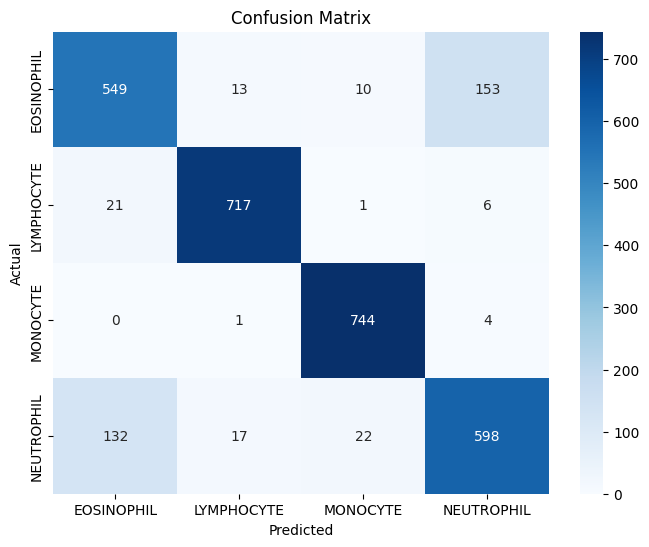

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(true_classes, pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels,
            yticklabels=class_labels)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


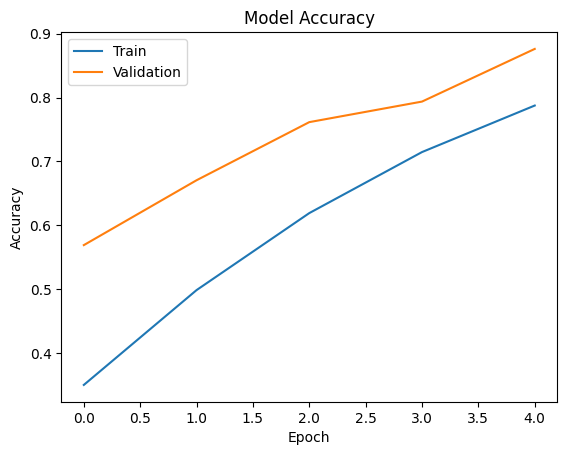

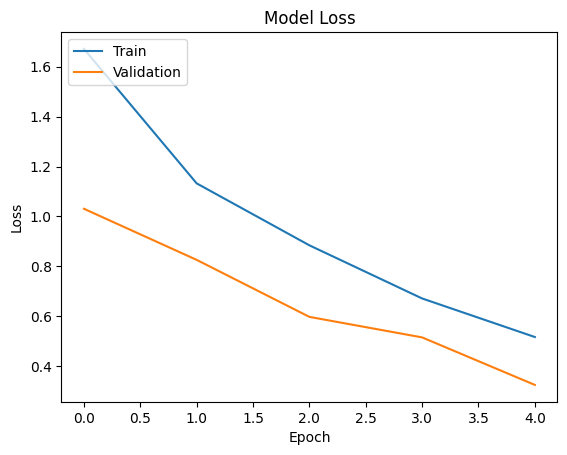

In [ ]:
# Accuracy Plot
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Loss Plot
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()


In [ ]:
model.save("Blood Cell.h5")


In [ ]:
from google.colab import files
files.download("Blood Cell.h5")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
print(train_generator.class_indices)

NameError: name 'train_generator' is not defined

In [ ]:
print(train.class_indices)

{'EOSINOPHIL': 0, 'LYMPHOCYTE': 1, 'MONOCYTE': 2, 'NEUTROPHIL': 3}
